## Introduction

### Contexte

L'agence Santé publique France souhaite améliorer sa base de données Open Food Facts et fait appel aux services de votre entreprise. Cette base de données open source est mise à la disposition de particuliers et d’organisations afin de leur permettre de connaître la qualité nutritionnelle de produits. 
 
Aujourd’hui, pour ajouter un produit à la base de données d'Open Food Facts, il est nécessaire de remplir de nombreux champs textuels et numériques, ce qui peut conduire à des erreurs de saisie et à des valeurs manquantes dans la base. 

L’agence Santé publique France confie à votre entreprise la création d’un système de suggestion ou d’auto-complétion pour aider les usagers à remplir plus efficacement la base de données. Dans un premier temps, vous devez vous concentrer sur la prise en main des données, et d’abord les nettoyer et les explorer. 

### Problématique

__Est-il possible de suggérer des valeurs pour certains champs lors de l'ajout d'un nouveau produit afin de réduire les erreurs de saisie et les valeurs manquantes dans la base de données Open Food Facts ?__

### Objectifs

- Identifier les variables cibles pour lesquelles il serait pertinent de suggérer des valeurs (plus de 50% de valeurs manquantes).
- Identifier les variables nécessaires pour lesquelles il est important d'avoir des données.
- Filtrer 
- Mettre en évidence les valeurs manquantes
- Identifier 3 méthodes adaptées (métiers) pour traiter ces valeurs manquantes.
- Automatiser les traitements pour éviter de répéter les opérations.


- Se servir de ces variables nécessaires pour tenter de faire des suggestions sur les variables avec des valeurs manquantes.

- Etablir la faisabilité de suggérer les valeurs manquantes pour une variable dont plus de 50% des valeurs sont manquantes.

### About RGPD

- Expliquer que la RGPD ne s'applique que dans le cadre de la manipulation de données personnelles.
- Détailler les grands principes des RGPD et en quoi ce projet reste tout de même cohérent avec ces principes.
- Expliquer ce qu'et une donnée personnelle et conclure que dans ce projet n'a pas de lien avec les RGPD.

## Imports and setup

In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional, Callable
import missingno as msno
import re

In [76]:
# Data collection

# Using low_memory = False to remove the DTypeWarning resulted in "code" column being modified.
# For example :
# low_memory = True : 11778, 11778
# low_memory = False : 0011778, 00011778
# All duplicates seem to be removed like this with low_memory = False

# Collect data and store it in a DataFrame
products = pd.read_csv('fr.openfoodfacts.org.products.csv', sep="\t", low_memory=True)

C:\Users\HCYF5290\AppData\Local\Temp\1\ipykernel_21096\3640485078.py:10: DtypeWarning: Columns (0,3,5,19,20,24,25,26,27,28,35,36,37,38,39,48) have mixed types. Specify dtype option on import or set low_memory=False.
  products = pd.read_csv('fr.openfoodfacts.org.products.csv', sep="\t", low_memory=True)


In [3]:
def check_for_mixed_types(df:pd.DataFrame) -> list:
    '''
    Checks a DataFrame for columns with inconsistent types.

    Parameters:
    df (pd.Dataframe): DataFrame to check

    Returns:
    List of column with inconsistent types.
    '''
    cols_mixed_types = []
    for col in df.columns:
        weird = (df[[col]].map(type) != df[[col]].iloc[0].apply(type)).any(axis=1)
        if len(df[weird]) > 0:
            cols_mixed_types.append(col)
    
    print(f"{len(cols_mixed_types)} column(s) have inconsistent types.")
    
    return cols_mixed_types

In [188]:
check_for_mixed_types(products)

55 column(s) have inconsistent types.


['code',
 'url',
 'creator',
 'created_t',
 'created_datetime',
 'last_modified_t',
 'product_name',
 'generic_name',
 'quantity',
 'packaging',
 'packaging_tags',
 'brands',
 'brands_tags',
 'categories',
 'categories_tags',
 'categories_fr',
 'origins',
 'origins_tags',
 'manufacturing_places',
 'manufacturing_places_tags',
 'labels',
 'labels_tags',
 'labels_fr',
 'emb_codes',
 'emb_codes_tags',
 'first_packaging_code_geo',
 'cities',
 'cities_tags',
 'purchase_places',
 'stores',
 'countries',
 'countries_tags',
 'countries_fr',
 'ingredients_text',
 'allergens',
 'allergens_fr',
 'traces',
 'traces_tags',
 'traces_fr',
 'serving_size',
 'additives',
 'additives_tags',
 'additives_fr',
 'ingredients_from_palm_oil_tags',
 'ingredients_that_may_be_from_palm_oil_tags',
 'nutrition_grade_fr',
 'pnns_groups_1',
 'pnns_groups_2',
 'states',
 'states_tags',
 'states_fr',
 'main_category',
 'main_category_fr',
 'image_url',
 'image_small_url']

In [4]:
# Set the seaborn theme for plots
sns.set_theme(palette="dark")

## General and basic data exploration

In [290]:
products.dtypes.head(60)

code                                           object
url                                            object
creator                                        object
created_t                                      object
created_datetime                               object
last_modified_t                                object
last_modified_datetime                         object
product_name                                   object
generic_name                                   object
quantity                                       object
packaging                                      object
packaging_tags                                 object
brands                                         object
brands_tags                                    object
categories                                     object
categories_tags                                object
categories_fr                                  object
origins                                        object
origins_tags                

<Axes: >

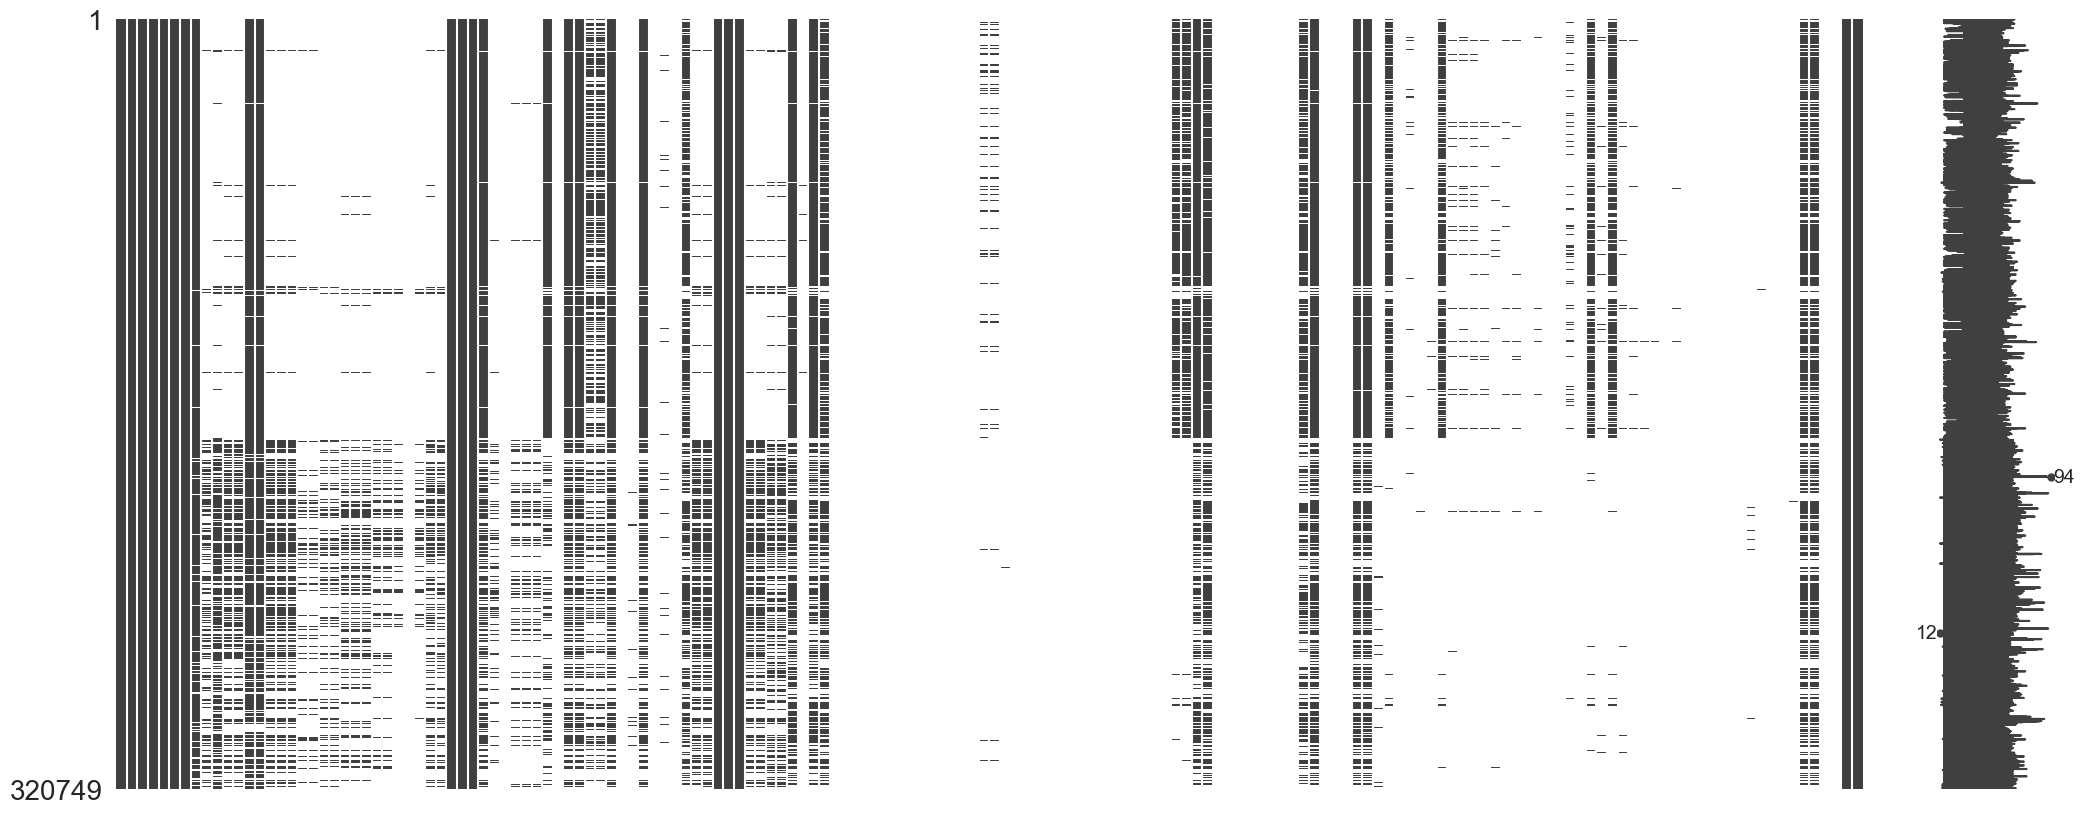

In [376]:
# Visualize missing values
msno.matrix(products)

In [5]:
def display_unique_values(s:pd.Series, df:pd.DataFrame):
    n_unique_values = df.loc[s.name, "nbr_unique_values"]
    if n_unique_values == 0:
        return "no value"
    if n_unique_values < 6:
        return ", ".join(f"{s.value_counts().index[i]} ({v} occurrences)" for i, v in enumerate(s.value_counts()))
    
    return "too many to display"


def add_additional_comment(s:pd.Series, df:pd.DataFrame, sensitivity:float):   
    value_counts = s.value_counts()

    if len(value_counts) > 0:
        # Calculate top common values based on sensitivity
        n_top_common_values = int(len(value_counts) * sensitivity)
        top_common_values = value_counts.values[:n_top_common_values]
        
        # Check if the top common values represent a significant proportion of the data
        if value_counts.quantile(1 - sensitivity) / value_counts.max() < 0.25 and n_top_common_values <= 10:
            sum_top_common_values = top_common_values.sum()
            top_common_values_prop = round(sum_top_common_values / df.loc[s.name, "nbr_non_null_values"], 2)
            top_common_values_info = [f"{value_counts.index[i]} ({value})" for i, value in enumerate(top_common_values)]
            
            # Print additional comments on common values
            return f"""First {n_top_common_values} unique values represent {top_common_values_prop * 100}% of total values : {', '.join(top_common_values_info)}"""
        
        return
    
    else:
        return "This column only contains null values."


def compute_modes(s:pd.Series):
    value_counts = s.value_counts()
    modes = s.mode()
    n_modes = len(modes)

    if n_modes > 0:
        return ", ".join(str(v) if i < 3 else f"... ({n_modes} elements)" for i, v in enumerate(modes[:min(n_modes, 4)])) + f" ({value_counts.values[0]} occurrence(s))"
    
    return


def get_df_variables_info(df:pd.DataFrame) -> pd.DataFrame:

    (n_rows, n_columns) = df.shape
    print(f"This DataFrame has {n_rows} rows and {n_columns} columns.")
    
    top_common_values_sensitivity = 0.15

    n_unique_values = df.nunique()
    n_values = df.count()

    df_info = pd.DataFrame({
        'column_type':df.dtypes,
        'missing_value_percentage': (df.isnull().mean()*100).round(3),
        'nbr_unique_values': n_unique_values,
        'nbr_null_values': df.isnull().sum(),
        'nbr_non_null_values': n_values,
        'duplicates_percentage':round(100-n_unique_values/(n_values.where(n_values != 0, np.nan))*100, 2),
        'mode': df.apply(compute_modes),
        'min': df.min(numeric_only=True),
        'max': df.max(numeric_only=True),
        'mean': df.mean(numeric_only=True),
        'median': df.median(numeric_only=True),
        'std': df.std(numeric_only=True)
        })

    df_info["unique_values"] = df.apply(display_unique_values, df=df_info)
    df_info["additional_comment"] = df.apply(add_additional_comment, df=df_info, sensitivity=top_common_values_sensitivity)

    return df_info


In [6]:
products_info = get_df_variables_info(products)

This DataFrame has 320772 rows and 162 columns.


## Dtypes fixes

### Incorrect datetime formats

Columns "last_modified_datetime" and "created_datetime" should be of dtype "datetime64[ns]". Let's try to convert them.

In [502]:
products["last_modified_datetime"] = pd.to_datetime(products["last_modified_datetime"])

ValueError: time data "en:belgium,en:france" doesn't match format "%Y-%m-%dT%H:%M:%S%z", at position 62064. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

Some datetime values are not formatted correctly. Let's identify the products that have this issue.

In [77]:
# Create a new column with formatted datetime, and highlight errors with NaT.
products["last_modified_datetime_formatted"] = pd.to_datetime(products["last_modified_datetime"], errors='coerce')
products["created_datetime_formatted"] = pd.to_datetime(products["created_datetime"], errors='coerce')

annoying_products = products.loc[products["last_modified_datetime_formatted"].isna() | products["created_datetime_formatted"].isna()]

print(f"Here are the {len(annoying_products)} indexes corresponding to products with incorrect datetime format:")
print(annoying_products.index.to_list())

Here are the 24 indexes corresponding to products with incorrect datetime format:
[187478, 189068, 189103, 189109, 189119, 189152, 189160, 189162, 189168, 189242, 189244, 189248, 189250, 189260, 189262, 189269, 189272, 189345, 189362, 189364, 189379, 189404, 189406, 189417]


In [8]:
annoying_products[["created_datetime", "last_modified_datetime"]]

,created_datetime,last_modified_datetime
187478,NaN,2017-03-08T16:54:15Z
189068,NaN,"en:belgium,en:france"
189103,"Dia,Sogeres",en:france
189109,NaN,"en:belgium,en:france,en:switzerland"
189119,SuperU,en:france
189152,Carrefour,en:france
189160,NaN,en:france
189162,Auchan,en:france
189168,NaN,en:france
189242,Carrefour market,en:france


Columns seem to have been mixed for most of those products. Reorganizing values in their correct column is quite difficult since there is no information on the product "code".
Those lines will just be dropped because it doesn't represent much data.  
Only index "187478" will be kept because it is a special case : all columns are correctly assigned, only the created_datetime and created_t are weird.  


In [78]:
# Remove index 187478 from annoying products
annoying_products = annoying_products.drop(index=187478)

# Remove annoying products from products
products = products.drop(index=annoying_products.index).reset_index(drop=True)

# Replace missing created_datetime with corresponding last_modified_datetime
# Ideally, we could impute created_datetime value based on created_t column, but created_t is 0 for index 187478.
products.loc[187478, "created_datetime_formatted"] = products.loc[187478, "last_modified_datetime_formatted"]

# Replace "created_datetime" with custom "created_datetime_formatted" column
products["created_datetime"] = products["created_datetime_formatted"]
# Replace "last_modified_datetime" with custom "last_modified_datetime_formatted" column
products["last_modified_datetime"] = products["last_modified_datetime_formatted"]
# Remove custom columns created previously to identify incorrect date formats
products = products.drop(columns=["created_datetime_formatted", "last_modified_datetime_formatted"])

### Minor notes

Columns "ingredients_from_palm_oil" and "ingredients_that_may_be_from_palm_oil" should be of type "object" instead of "float64", but since there are only null values it doesn't really matter.  
Same thing for column "nutrition_grade_uk".

In [ ]:
# Update products_info
products_info = get_df_variables_info(products)

This DataFrame has 320749 rows and 162 columns.


## Data cleaning

### Similar columns

According to description of fields from the provided documentation :  

> "fields that end with _tags are comma separated list of tags (e.g. categories_tags is the set of normalized tags computed from the categories field)"

Therefore, when several columns contain the same data ("countries", "countries_tags" and "countries_fr" for example), the column wth suffix "_tags" will be preferred because it is normalized.

However, some similar columns do not have the same amount of non-null values.

In [139]:
def compare_similar_columns_missing_values(df:pd.DataFrame, base_col_name:str, include_columns:list[str]=["product_name"], exclude_columns:list[str]=[]):
    # Get other simimar columns
    columns = [c for c in products if c.startswith(base_col_name) and c not in exclude_columns]

    # Look for products with at least 1 missing value among the columns AND 1 non missing value among the columns
    n_values = df[columns].count(axis=1) # Count non missing values among the columns
    condition = np.logical_and(1 <= n_values, n_values < len(columns)) # Build the condition

    return df.loc[condition, include_columns + columns] # Return products matching the condition

In [143]:
compare_similar_columns_missing_values(df=products, base_col_name="brands")

,product_name,brands,brands_tags


It seems some values should actually be considered as missing values.  
Let's identify as many of those hidden missing values as possible in the columns of type "object".

In [54]:
def standardize_str(s:str, escape_chars:list=[]):
    if pd.isnull(s):
        return s
    escape_pattern = ''.join(re.escape(char) for char in escape_chars)
    pattern = r'[^\w' + escape_pattern + r']'
    return re.sub(pattern, '', str(s)).lower()

In [85]:
def find_hidden_missing_values(df:pd.DataFrame, standardize:bool=True, print_result:bool = True, impute_nan:bool=False, additional_hidden_null_values:list[str] = ["unknown", "null", "nan", "na", "0", "inconnu", "unavailable", "not stated"]):   
    df_copy = df.copy()

    for col in df_copy:
        if standardize:
            data = df_copy[col].map(standardize_str)
        else:
            data = df_copy[col]
        contains_alphanumeric = data.str.contains(pat=r'\w', na=True, regex=True)
        hidden_null_values_condition = ~contains_alphanumeric | data.isin(additional_hidden_null_values)
        
        if hidden_null_values_condition.any():
            if print_result:
                hidden_null_values = df_copy.loc[hidden_null_values_condition, col]
                print(f"{col}:\n{hidden_null_values}\n{"*"*30}\n")
            if impute_nan:
                df_copy.loc[hidden_null_values_condition, col] = np.nan
    
    return df_copy

In [79]:
# Identify columns with type "object", which can contain hidden null values.
products_object_columns = products.select_dtypes(include=object)
# Remove columns with only null values
products_object_columns = products_object_columns.dropna(axis='columns', how='all')

In [84]:
find_hidden_missing_values(df=products_object_columns, standardize=True, print_result=True, impute_nan=False)

created_t:
187478    0
Name: created_t, dtype: object
******************************

product_name:
625           
248202    n.a!
294495        
315095        
Name: product_name, dtype: object
******************************

generic_name:
174732     
179867     
Name: generic_name, dtype: object
******************************

quantity:
23844            
45304            
61244           0
86250            
87335            
96396            
99184            
105883           
115135           
115213          0
144820           
174797           
175078           
180919           
182489           
184358           
184680          /
186293          /
208497           
213267          0
233731          -
234300          /
237539           
243525          ?
243783          /
248062           
253040         na
255789           
256348           
256917           
258099           
259643           
260018           
262314           
262442           
262689           
262849      

In [86]:
# Fix some product names after checking their page using the provided url
products.loc[268391, "product_name"] = "5 stars"
products.loc[268392, "product_name"] = "3 stars"
products.loc[315650, "product_name"] = "Dors Tequila"

In [87]:
# Update products_objects_columns to take last changes into account
products_object_columns = products.select_dtypes(include=object)
products_object_columns = products_object_columns.dropna(axis='columns', how='all')

products_object_columns = find_hidden_missing_values(df=products_object_columns, standardize=True, print_result=False, impute_nan=True)

In [ ]:
# Replace objsct columns with the new object columns (with hiddent null values imputed as NaN)
products[products_object_columns.columns] = products_object_columns

"allergens":  
- mix of english and other languages  
- mix of different cases    

In [89]:
# Update products_info
products_info = get_df_variables_info(products)

This DataFrame has 320749 rows and 162 columns.


It seem "additives" column contains information on all ingredients, and not only on additives as it is illustrated in the next cell.  
In addition, word parsing seems to be done quite poorly and does not bring relevant information.  
This column will be removed later for the rest of the analysis.

In [ ]:
# Illustrate values in "additives" column compared to values in "ingredients_text" column
with pd.option_context('display.max_colwidth', None):
    display(products.loc[products["additives"].notna(), ["product_name", "ingredients_text", "additives"]])

,product_name,ingredients_text,additives
1,Banana Chips Sweetened (Whole),"Bananas, vegetable oil (coconut oil, corn oil and/or palm oil) sugar, natural banana flavor.",[ bananas -> en:bananas ] [ vegetable-oil -> en:vegetable-oil ] [ oil -> en:oil ] [ coconut-oil -> en:coconut-oil ] [ oil -> en:oil ] [ corn-oil-and-or-palm-oil-sugar -> en:corn-oil-and-or-palm-oil-sugar ] [ oil-and-or-palm-oil-sugar -> en:oil-and-or-palm-oil-sugar ] [ and-or-palm-oil-sugar -> en:and-or-palm-oil-sugar ] [ or-palm-oil-sugar -> en:or-palm-oil-sugar ] [ palm-oil-sugar -> en:palm-oil-sugar ] [ oil-sugar -> en:oil-sugar ] [ sugar -> en:sugar ] [ natural-banana-flavor -> en:natural-banana-flavor ] [ banana-flavor -> en:banana-flavor ] [ flavor -> en:flavor ]
2,Peanuts,"Peanuts, wheat flour, sugar, rice flour, tapioca starch, salt, leavening (ammonium bicarbonate, baking soda), soy sauce (water, soybeans, wheat, salt), potato starch.",[ peanuts -> en:peanuts ] [ wheat-flour -> en:wheat-flour ] [ flour -> en:flour ] [ sugar -> en:sugar ] [ rice-flour -> en:rice-flour ] [ flour -> en:flour ] [ tapioca-starch -> en:tapioca-starch ] [ starch -> en:starch ] [ salt -> en:salt ] [ leavening -> en:leavening ] [ ammonium-bicarbonate -> en:ammonium-bicarbonate ] [ bicarbonate -> en:bicarbonate ] [ baking-soda -> en:baking-soda ] [ soda -> en:soda ] [ soy-sauce -> en:soy-sauce ] [ sauce -> en:sauce ] [ water -> en:water ] [ soybeans -> en:soybeans ] [ wheat -> en:wheat ] [ salt -> en:salt ] [ potato-starch -> en:potato-starch ] [ starch -> en:starch ]
3,Organic Salted Nut Mix,"Organic hazelnuts, organic cashews, organic walnuts almonds, organic sunflower oil, sea salt.",[ organic-hazelnuts -> en:organic-hazelnuts ] [ hazelnuts -> en:hazelnuts ] [ organic-cashews -> en:organic-cashews ] [ cashews -> en:cashews ] [ organic-walnuts-almonds -> en:organic-walnuts-almonds ] [ walnuts-almonds -> en:walnuts-almonds ] [ almonds -> en:almonds ] [ organic-sunflower-oil -> en:organic-sunflower-oil ] [ sunflower-oil -> en:sunflower-oil ] [ oil -> en:oil ] [ sea-salt -> en:sea-salt ] [ salt -> en:salt ]
4,Organic Polenta,Organic polenta,[ organic-polenta -> en:organic-polenta ] [ polenta -> en:polenta ]
5,Breadshop Honey Gone Nuts Granola,"Rolled oats, grape concentrate, expeller pressed canola oil, sunflower seeds, almonds, walnuts oat bran, sesame seeds, cashews, natural vitamin e.",[ rolled-oats -> en:rolled-oats ] [ oats -> en:oats ] [ grape-concentrate -> en:grape-concentrate ] [ concentrate -> en:concentrate ] [ expeller-pressed-canola-oil -> en:expeller-pressed-canola-oil ] [ pressed-canola-oil -> en:pressed-canola-oil ] [ canola-oil -> en:canola-oil ] [ oil -> en:oil ] [ sunflower-seeds -> en:sunflower-seeds ] [ seeds -> en:seeds ] [ almonds -> en:almonds ] [ walnuts-oat-bran -> en:walnuts-oat-bran ] [ oat-bran -> en:oat-bran ] [ bran -> en:bran ] [ sesame-seeds -> en:sesame-seeds ] [ seeds -> en:seeds ] [ cashews -> en:cashews ] [ natural-vitamin-e -> en:natural-vitamin-e ] [ vitamin-e -> en:vitamin-e ] [ e -> en:e ]
...,...,...,...
320735,Miel de Camargue,Miel,[ miel -> fr:miel ]
320740,Thé vert Earl grey,"thé vert, arôme naturel bergamote avec autres arômes naturels, écorces d'orange douce 3%",[ the-vert -> fr:the-vert ] [ the -> fr:the ] [ arome-naturel-bergamote-avec-autres-aromes-naturels -> fr:arome-naturel-bergamote-avec-autres-aromes-naturels ] [ arome-naturel-bergamote-avec-autres-aromes -> fr:arome-naturel-bergamote-avec-autres-aromes ] [ arome-naturel-bergamote-avec-autres -> fr:arome-naturel-bergamote-avec-autres ] [ arome-naturel-bergamote-avec -> fr:arome-naturel-bergamote-avec ] [ arome-naturel-bergamote -> fr:arome-naturel-bergamote ] [ arome-naturel -> fr:arome-naturel ] [ arome -> fr:arome ] [ ecorces-d-orange-douce-3 -> fr:ecorces-d-orange-douce-3 ] [ ecorces-d-orange-douce -> fr:ecorces-d-orange-douce ] [ ecorces-d-orange -> fr:ecorces-d-orange ] [ ecorces-d -> fr:ecorces-d ] [ ecorces -> fr:ecorces ]
320742,Rillette d'oie,"viande d'oie, graisse d

In [175]:
np.where((products["traces_fr"].value_counts().values - products["traces_tags"].value_counts().values[:-1]) == 1)[0]

array([25])

In [185]:
products["traces_fr"].value_counts().head(26)

traces_fr
Fruits à coque                                     2051
Lait                                                844
Œufs                                                788
Gluten                                              718
Fruits à coque,Arachides                            564
Lait,Fruits à coque                                 552
Fruits à coque,Soja                                 525
Soja                                                517
Anhydride sulfureux et sulfites                     486
Gluten,Fruits à coque                               451
Céleri                                              416
Graines de sésame                                   310
Œufs,Fruits à coque                                 292
Fruits à coque,Graines de sésame                    262
Lait,Fruits à coque,Soja                            255
Gluten,Lait,Fruits à coque                          242
Moutarde                                            217
Œufs,Lait                             

In [192]:
products["traces_fr"].value_counts()[products["traces_fr"].value_counts().index.str.lower().str.contains("phenylalanine")]

traces_fr
Phenylalanine                                                              169
en:Phenylalanine                                                            13
Contient-une-source-de-phenylalanine                                         8
Source-de-phenylalanine                                                      4
Fruits à coque,Graines de sésame,Phenylalanine                               2
Lait,Phenylalanine                                                           2
Fruits à coque,Graines de sésame,Source-de-phenylalanine                     1
en:Phenylketonurics-contains-phenylalanine                                   1
Œufs,Phenylalanine                                                           1
Gluten,Phenylalanine                                                         1
Anhydride sulfureux et sulfites,en:Phenylalanine                             1
Fruits à coque,Phenylalanine                                                 1
Lait,en:Phenylalanine                     

In [191]:
products["traces_tags"].value_counts()[products["traces_tags"].value_counts().index.str.contains("phenylalanine")]

traces_tags
fr:phenylalanine                                                                 168
en:phenylalanine                                                                  13
fr:contient-une-source-de-phenylalanine                                            8
fr:source-de-phenylalanine                                                         4
en:nuts,en:sesame-seeds,fr:phenylalanine                                           2
en:milk,fr:phenylalanine                                                           2
en:nuts,fr:phenylalanine                                                           1
en:sulphur-dioxide-and-sulphites,en:phenylalanine                                  1
en:gluten,fr:phenylalanine                                                         1
en:eggs,fr:phenylalanine                                                           1
en:contient-une-source-de-phenylalanine                                            1
en:phenylketonurics-contains-phenylalanine           

In [155]:
# Check that columns "image_small_url" and "image_url" are almost identical. Only the 7th character from the end changes. 
# All urls in image_small_url end with "200.jpg" when all urls in image_url end with "400.jpg"
products.loc[(products["image_small_url"] != (products["image_url"].str[:-7] + "2" + products["image_url"].str[-6:])) & (products["image_url"].notna()), ["image_small_url", "image_url"]]

,image_small_url,image_url


In [ ]:
# Only difference between "state" and "states_tags" columns is that :
# - values are separated by ", " in "states" column (with whitespace)
# - values are separated by "," in "states_tags" column (without whitespace)
products.loc[(products["states"].str.split(', ') != products["states_tags"].str.split(',')) & (products["states"].notna()), ["states", "states_tags"]]

,states,states_tags


In [214]:
products.loc[(products["countries_fr"] != products["countries_tags"]) & (products["countries"].notna()), ["countries", "countries_tags"]].value_counts()

countries                                                                                                                                                                                                            countries_tags                                                                                                                                                                                                                                                                          
US                                                                                                                                                                                                                   en:united-states                                                                                                                                                                                                                                                                            169928
Fr

In [220]:
products["countries_fr"].str.split(',').explode().value_counts().head(60)

countries_fr
États-Unis                  173467
France                       98440
Suisse                       16929
Allemagne                     8640
Royaume-Uni                   5626
Espagne                       5393
Belgique                      3456
Australie                     2149
Italie                        1364
Russie                        1362
Canada                         962
Portugal                       821
Pays-Bas                       697
Autriche                       438
Danemark                       409
Brésil                         342
République tchèque             302
Hongrie                        267
Thaïlande                      245
Roumanie                       233
La Réunion                     231
Guadeloupe                     222
Luxembourg                     199
Irlande                        198
Japon                          194
Chine                          186
Pologne                        186
Maroc                          181
Tunisie

In [228]:
products["countries_fr"].str.split(',').explode().value_counts().loc[products["countries_fr"].str.split(',').explode().value_counts().values == 1]

countries_fr
en:United-states-of-america    1
Marseille-6                    1
en:An                          1
Burundi                        1
Porto Rico                     1
                              ..
en:ประเทศออสเตรเลีย            1
en:ประเทศไทย                   1
en:สหราชอาณาจักร               1
en:भारत                        1
Bangladesh                     1
Name: count, Length: 86, dtype: int64

In [224]:
products["countries_tags"].str.split(',').explode().value_counts().loc[products["countries_tags"].str.split(',').explode().value_counts().values == 1]

countries_tags
en:kina                1
en:frankrike           1
en:croacia             1
fr:marseille-6         1
en:etats-unis          1
                      ..
en:ประเทศออสเตรเลีย    1
en:ประเทศไทย           1
en:สหราชอาณาจักร       1
en:भारत                1
en:bangladesh          1
Name: count, Length: 88, dtype: int64

In [ ]:
products["countries_tags"].str.split(',').explode().value_counts()

countries_tags
en:united-states       173467
en:france               98439
en:switzerland          16929
en:germany               8640
en:united-kingdom        5626
                        ...  
en:ประเทศออสเตรเลีย         1
en:ประเทศไทย                1
en:สหราชอาณาจักร            1
en:भारत                     1
en:bangladesh               1
Name: count, Length: 267, dtype: int64

In [ ]:
# Remove irrelevant columns
columns_to_drop = [
    "image_small_url", # duplicate of image_url
    "additives", # irrelevant column (see previously)
    "additives_fr", # french duplicate of additives_tags
    "allergens_fr", # empty
    "brands", # unstandardized duplicate of brands_tags
    "categories", # unstandardized duplicate of categories_tags
    "categories_fr", # french duplicate of categories_tags
    "cities", # empty
    "countries" # unstandardized duplicate of countries_tags
    "countries_fr", # french duplicate of countries_tags
    "emb_codes", # unstandardized duplicate of emb_code_tags
    "ingredients_from_palm_oil", # empty
    "ingredients_that_may_be_from_palm_oil", # empty
    "labels", # unstandardized duplicate of labels_tags
    "labels_fr", # french duplicate of labels_tags
    "main_category_fr", # french duplicate of main_category
    "origins", # unstandardized duplicate of origins_tags
    "packaging", # unstandardized duplicate of packaging_tags
    "states", # duplicate of states_tags
    "states_fr", # french duplicate of state_tags
]

products.drop(columns=columns_to_drop, inplace=True)

INVESTIGATION TO PERFORM :
- Check differences between countries and countries_tags
- Check differences between countries_fr and countries_tags
- Check if the fact that main_category is not standardized causes any issue of hidden duplicates
- Compare pnns_groups_1 and pnns_groups_2

## Target choice

At first, we'll start by establishing the feasibility of suggesting missing values for a variable where more than 50% of the values are missing.

In [91]:
# Visualize catetgory variables with at least 50% of missing values
products_info.loc[(products_info["column_type"] == "object") & (products_info["missing_value_percentage"] > 50)].dropna(axis=1, how='all')

,column_type,missing_value_percentage,nbr_unique_values,nbr_null_values,nbr_non_null_values,duplicates_percentage,mode,unique_values,additional_comment
additives_fr,object,51.775,41537,166069,154680,73.15,E322 - Lécithines (8264 occurrence(s)),too many to display,None
additives_tags,object,51.775,41537,166069,154680,73.15,en:e322 (8264 occurrence(s)),too many to display,None
allergens,object,91.170,12919,292426,28323,54.39,blé (1279 occurrence(s)),too many to display,None
allergens_fr,object,100.000,0,320749,0,NaN,None,no value,This column only contains null values.
categories,object,73.690,36976,236360,84389,56.18,"Snacks sucrés,Biscuits et gâteaux,Biscuits (30...",too many to display,None
categories_fr,object,73.690,21142,236360,84389,74.95,"Snacks sucrés,Biscuits et gâteaux,Biscuits (80...",too many to display,None
categories_tags,object,73.690,21142,236360,84389,74.95,"en:sugary-snacks,en:biscuits-and-cakes,en:bisc...",too many to display,None
cities,object,100.000,0,320749,0,NaN,None,no value,This column only contains null values.
cities_tags,object,93.672,2570,300452,20297,87.34,theix-morbihan-france (270 occurrence(s)),too many to display,None
emb_codes,object,90.866,8459,291452,29297,71.13,EMB 56251E (218 occurrence(s)),too many to display,None


The chosen target is "main_category_fr". It has 73.70% missing values.  
It seems to be a simple translation of "main_category" column. Let's visualize differences between those 2 columns.

In [11]:
products[["main_category", "main_category_fr"]].value_counts()

main_category                       main_category_fr                       
en:beverages                        Boissons                                   6054
en:groceries                        Epicerie                                   2902
en:chocolates                       Chocolats                                  2789
en:plant-based-foods-and-beverages  Aliments et boissons à base de végétaux    2745
en:canned-foods                     Conserves                                  2519
                                                                               ... 
en:blended-scotch-whisky            en:Blended-scotch-whisky                      1
de:antipasti                        de:Antipasti                                  1
en:blinis                           en:Blinis                                     1
de:apfel-und-mango-saft             de:Apfel-und-mango-saft                       1
ar:juice                            ar:Juice                                      1


There are as many unique combinations of "main_category" + "main_category_fr" as there are unique values for "main_cateogry" and for "main_category_fr".

In [12]:
products[["main_category", "main_category_fr"]].value_counts().head(60)

main_category                       main_category_fr                       
en:beverages                        Boissons                                   6054
en:groceries                        Epicerie                                   2902
en:chocolates                       Chocolats                                  2789
en:plant-based-foods-and-beverages  Aliments et boissons à base de végétaux    2745
en:canned-foods                     Conserves                                  2519
en:biscuits                         Biscuits                                   2097
en:meals                            Plats préparés                             2079
en:sugary-snacks                    Snacks sucrés                              1946
en:frozen-foods                     Surgelés                                   1889
en:breakfasts                       Petit-déjeuners                            1793
en:cheeses                          Fromages                                   1785


In [13]:
products[["main_category", "main_category_fr"]].value_counts().sample(60)

main_category                         main_category_fr                    
en:coca-cola                          en:Coca-cola                              1
it:charcuteries                       it:Charcuteries                           1
en:juice-beverage                     en:Juice-beverage                         1
de:schupfnudeln                       de:Schupfnudeln                           3
fr:gauffres                           Gauffres                                  1
en:indian-sauces                      en:Indian-sauces                          1
en:sweetcorn-and-peas                 en:Sweetcorn-and-peas                     1
fr:feuilles-de-brick                  Feuilles-de-brick                        12
en:kekse                              en:Kekse                                  1
fr:insectes                           Insectes                                  5
en:beer-batter-fries                  en:Beer-batter-fries                      1
fr:cremes-de-pruneaux  

Only values appearing the most seem to have been translated in column "main_category_fr".  
Format is quite inconsistent in column "main_category_fr". Use of spaces, dashes, sometimes there is the language id, sometimes not, ...
Some values are categorized as in a language but are actually in another language. For example : 'en:confitures-allegees', 'en:pate-a-tartiner-pomme-poire', 'fr:spicies', 'en:levures', 'en:boissons-edulcorees', ...


Format of column "main_category" is more consistent. This column will be chosen instead of "main_category_fr".

In [140]:
def visualize_col_completeness(df:pd.DataFrame) -> None:
    # Visualize percentage of null values in columns of non_target_data
    fig, ax = plt.subplots(figsize=(25, (len(df.columns) - 25)*0.5))
    msno.bar(df, sort="ascending", ax=ax)
    ax.set_title("Visualization of columns completeness", fontdict={'fontsize':20})

In [83]:
def filter_to_keep_relevant_features(df: pd.DataFrame, target:str, visualize:bool=False) -> pd.DataFrame:

    # Remove products where there is no value for target variable
    filtered_products = df.dropna(subset=target)

    # Separate the target from the rest of the dataset
    target_data = filtered_products[target]
    non_target_data = filtered_products.drop(columns=target)

    if visualize:
        visualize_col_completeness(non_target_data)

    # Define columns that will be irrelevant no matter what target is choosen.
    always_irrelevant_columns = ["last_modified_datetime", "creator", "url", "last_modified_t", "created_datetime", "created_t", "image_small_url", "image_url"]
    always_relevant_columns = ["code", "product_name", "brands_tags", "countries_tags", "quantity"]

    # Define maximum number of features to keep, including always_relevant_columns
    max_nbr_features = 30

    # Get filled data percentage of each column
    filled_data_percentage = non_target_data.notna().mean().sort_values(ascending=False)

    # Only keep most filled columns which are not irrelevant
    relevant_columns = filled_data_percentage[~filled_data_percentage.index.isin(always_irrelevant_columns + always_relevant_columns)][:(max_nbr_features - len(always_relevant_columns))].index.tolist()
    relevant_non_target_data = non_target_data[always_relevant_columns + relevant_columns]

    # Remove duplicates (i.e. products with the same code, because even though they have different urls, those all redirect to the same page of the same product.)
    return relevant_non_target_data.drop_duplicates(subset=["code"])

In [213]:
filtered_data = filter_to_keep_relevant_features(df=products, target="main_category")

In [214]:
filtered_data_info = get_df_variables_info(filtered_data)

This DataFrame has 84362 rows and 30 columns.


C:\Users\HCYF5290\AppData\Local\Temp\1\ipykernel_12720\1951515332.py:36: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  modes = s.mode()
